In [1]:
import mlflow 
mlflow.autolog()

import mlflow
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from tqdm import tqdm
import os

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

2026/03/21 17:17:50 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/03/21 17:17:50 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.


In [2]:
mlflow.set_experiment("Reco Agricole")
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI"))

In [3]:
base_df = pd.read_csv("../data/processed/merged_df.csv")
base_df

,yield (t/ha),direction,soil,item,rain (mm),temp (C),synthetic
0,6.555816,West,Sandy,Cotton,897.077239,27.676966,False
1,8.527341,South,Clay,Rice,992.673282,18.026142,False
2,1.127443,North,Loam,Barley,147.998025,29.794042,False
3,6.517573,North,Sandy,Soybean,986.866331,16.644190,False
4,7.248251,South,Silt,Wheat,730.379174,31.620687,False
...,...,...,...,...,...,...,...
1028237,2.258100,South,Clay,Rice,657.000000,19.760000,True
1028238,0.306600,South,Clay,Sorghum,657.000000,19.760000,True
1028239,1.314200,South,Clay,Soybean,657.000000,19.760000,True
1028240,2.222200,South,Clay,Sweet potatoes,657.000000,19.760000,True


In [4]:
base_columns = base_df.columns

In [5]:
polynomial_columns = []
# Polynomial features
for i in range(1, 4):
    rain = base_df["rain (mm)"] ** i
    temp = base_df["temp (C)"] ** i

    if not i == 1:
        base_df[f"rain (mm)^{i}"] = rain
        base_df[f"temp (C)^{i}"] = temp
        polynomial_columns.append(f"rain (mm)^{i}")
        polynomial_columns.append(f"temp (C)^{i}")
    
    base_df[f"temp (C)^{i} rain (mm)^{4-i}"] = temp * base_df[f"rain (mm)"] ** (4-i)

    polynomial_columns.append(f"temp (C)^{i} rain (mm)^{4-i}")

base_df.head()

,yield (t/ha),direction,soil,item,rain (mm),temp (C),synthetic,temp (C)^1 rain (mm)^3,rain (mm)^2,temp (C)^2,temp (C)^2 rain (mm)^2,rain (mm)^3,temp (C)^3,temp (C)^3 rain (mm)^1
0,6.555816,West,Sandy,Cotton,897.077239,27.676966,False,1.998058e+10,804747.572929,766.014468,6.164483e+08,7.219207e+08,21200.956662,1.901890e+07
1,8.527341,South,Clay,Rice,992.673282,18.026142,False,1.763282e+10,985400.244040,324.941805,3.201977e+08,9.781805e+08,5857.447194,5.814531e+06
2,1.127443,North,Loam,Barley,147.998025,29.794042,False,9.658222e+07,21903.415491,887.684963,1.944333e+07,3.241662e+06,26447.723453,3.914211e+06
3,6.517573,North,Sandy,Soybean,986.866331,16.644190,False,1.599697e+10,973905.155926,277.029067,2.698000e+08,9.611142e+08,4610.924482,4.550366e+06
4,7.248251,South,Silt,Wheat,730.379174,31.620687,False,1.232016e+10,533453.738464,999.867870,5.333833e+08,3.896235e+08,31616.509323,2.309204e+07


In [6]:
categorial_columns = ["direction", "soil", "item"]
df_ohe = pd.get_dummies(base_df, columns=categorial_columns, drop_first=True)
df_ohe.head()

,yield (t/ha),rain (mm),temp (C),synthetic,temp (C)^1 rain (mm)^3,rain (mm)^2,temp (C)^2,temp (C)^2 rain (mm)^2,rain (mm)^3,temp (C)^3,...,item_Cotton,item_Maize,item_Plantains and others,item_Potatoes,item_Rice,item_Sorghum,item_Soybean,item_Sweet potatoes,item_Wheat,item_Yams
0,6.555816,897.077239,27.676966,False,1.998058e+10,804747.572929,766.014468,6.164483e+08,7.219207e+08,21200.956662,...,True,False,False,False,False,False,False,False,False,False
1,8.527341,992.673282,18.026142,False,1.763282e+10,985400.244040,324.941805,3.201977e+08,9.781805e+08,5857.447194,...,False,False,False,False,True,False,False,False,False,False
2,1.127443,147.998025,29.794042,False,9.658222e+07,21903.415491,887.684963,1.944333e+07,3.241662e+06,26447.723453,...,False,False,False,False,False,False,False,False,False,False
3,6.517573,986.866331,16.644190,False,1.599697e+10,973905.155926,277.029067,2.698000e+08,9.611142e+08,4610.924482,...,False,False,False,False,False,False,True,False,False,False
4,7.248251,730.379174,31.620687,False,1.232016e+10,533453.738464,999.867870,5.333833e+08,3.896235e+08,31616.509323,...,False,False,False,False,False,False,False,False,True,False


# Linear Regression

In [22]:
tags = {
    "phase": "baseline",
    "model_family": "linear_regression",
    "dataset": "synth+real",
    "columns": "base+polynomial"
}
with mlflow.start_run(experiment_id="1", tags=tags, run_name="linear_regression"):
    lr = LinearRegression()

    X_train, X_test, y_train, y_test = train_test_split(df_ohe.drop("yield (t/ha)", axis=1), df_ohe["yield (t/ha)"], test_size=0.2, random_state=42)

    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    print(f"R2: {r2:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}")

    mlflow.log_metric("r2", r2)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mape", mape)

2026/03/11 19:52:14 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format."


R2: 0.36
RMSE: 1.76
MAE: 1.03
MAPE: 0.34
🏃 View run linear_regression at: http://localhost:5000/#/experiments/1/runs/5fb365bcae57413c9a0abb3cdb6f1436
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [23]:
tags = {
    "phase": "baseline",
    "model_family": "linear_regression",
    "dataset": "synth+real",
    "columns": "base"
}
with mlflow.start_run(experiment_id="1", tags=tags, run_name="linear_regression"):
    lr = LinearRegression()

    X_train, X_test, y_train, y_test = train_test_split(df_ohe.drop(polynomial_columns + ["yield (t/ha)"], axis=1), df_ohe["yield (t/ha)"], test_size=0.2, random_state=42)

    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    print(f"R2: {r2:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}")

    mlflow.log_metric("r2", r2)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mape", mape)

2026/03/11 19:52:32 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format."


R2: 0.54
RMSE: 1.50
MAE: 1.01
MAPE: 0.34
🏃 View run linear_regression at: http://localhost:5000/#/experiments/1/runs/bcda73ec373746bcb147409364f1fb1c
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [24]:
tags = {
    "phase": "baseline",
    "model_family": "linear_regression",
    "dataset": "real",
    "columns": "base+polynomial"
}
with mlflow.start_run(experiment_id="1", tags=tags, run_name="linear_regression"):
    lr = LinearRegression()

    X_train, X_test, y_train, y_test = train_test_split(df_ohe.drop("yield (t/ha)", axis=1)[df_ohe["synthetic"] == False], df_ohe["yield (t/ha)"][df_ohe["synthetic"] == False], test_size=0.2, random_state=42)

    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    print(f"R2: {r2:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}")

    mlflow.log_metric("r2", r2)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mape", mape)

2026/03/11 19:52:55 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format."


R2: 0.59
RMSE: 1.09
MAE: 0.89
MAPE: 0.30
🏃 View run linear_regression at: http://localhost:5000/#/experiments/1/runs/8e25b243e264484aa083e9e5a753b506
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [25]:
tags = {
    "phase": "baseline",
    "model_family": "linear_regression",
    "dataset": "real",
    "columns": "base"
}
with mlflow.start_run(experiment_id="1", tags=tags, run_name="linear_regression"):
    lr = LinearRegression()

    X_train, X_test, y_train, y_test = train_test_split(df_ohe.drop(polynomial_columns + ["yield (t/ha)"], axis=1)[df_ohe["synthetic"] == False], df_ohe["yield (t/ha)"][df_ohe["synthetic"] == False], test_size=0.2, random_state=42)

    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    print(f"R2: {r2:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}")

    mlflow.log_metric("r2", r2)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mape", mape)

2026/03/11 19:53:13 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format."


R2: 0.59
RMSE: 1.09
MAE: 0.89
MAPE: 0.30
🏃 View run linear_regression at: http://localhost:5000/#/experiments/1/runs/8e7ec10c6ea64a058924d6a22a45cefd
🧪 View experiment at: http://localhost:5000/#/experiments/1


# Random Forest

In [26]:
def train_rf_kfold(df, target_col, n_splits=5, tags={}, params={}):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    if not params:
        params = {
            "n_estimators": 10,
            "max_depth": 5,
            "random_state": 42,
            "n_jobs": -1
        }
    
    with mlflow.start_run(run_name="random_forest_permutation", tags=tags):
        mlflow.log_params(params)
        
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        final_scores = []
        final_mae = []
        final_mape = []

        # Store permutation importance results across folds
        perm_importances = []
        
        for fold, (train_idx, val_idx) in tqdm(enumerate(kf.split(X))):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            model = RandomForestRegressor(**params)
            model.fit(X_train, y_train)
            
            # 1. Standard Metrics
            fold_preds = model.predict(X_val)
            fold_rmse = root_mean_squared_error(y_val, fold_preds)
            final_scores.append(fold_rmse)
            
            fold_mae = mean_absolute_error(y_val, fold_preds)
            final_mae.append(fold_mae)

            fold_mape = mean_absolute_percentage_error(y_val, fold_preds)
            final_mape.append(fold_mape)

            # mlflow.log_metric(f"fold_{fold}_rmse", fold_rmse)
            # mlflow.log_metric(f"fold_{fold}_mae", fold_mae)
            
            # 2. Permutation Importance (calculated on validation set)
            # n_repeats=5 is a good balance between speed and statistical significance
            r = permutation_importance(model, X_val, y_val, n_repeats=5, 
                                       random_state=42, n_jobs=-1)
            perm_importances.append(r.importances_mean)
            
        # Calculate Aggregates
        avg_rmse = np.mean(final_scores)
        avg_mae = np.mean(final_mae)
        avg_mape = np.mean(final_mape)
        avg_perm_importance = np.mean(perm_importances, axis=0)
        mlflow.log_metric("rmse", avg_rmse)
        mlflow.log_metric("mae", avg_mae)
        mlflow.log_metric("mape", avg_mape)
        
        # Log the final model
        mlflow.sklearn.log_model(model, "random_forest_model")
        print(f"Final Average RMSE: {avg_rmse} | Final Average MAE: {avg_mae}")

        # 3. Create and Log Importance Plot
        feat_df = pd.DataFrame({
            "feature": X.columns, 
            "permutation_importance": avg_perm_importance
        }).sort_values("permutation_importance", ascending=True)
        zero_importance = feat_df[feat_df["permutation_importance"] < 0.001]
        print(zero_importance["feature"].sort_values().values)
        
        feature_importance = feat_df[feat_df["permutation_importance"] >= 0.001]

        plt.figure(figsize=(10, 6))
        plt.barh(feature_importance["feature"], feature_importance["permutation_importance"])
        plt.xlabel("Decrease in RMSE score")
        plt.title("Permutation Importance (Average over Folds)")
        plt.tight_layout()
        
        # Save and log the plot to MLflow
        fig = plt.gcf()
        mlflow.log_figure(fig, "permutation_importance.png")
        plt.show()

    return model, avg_rmse

0it [00:00, ?it/s]2026/03/11 19:53:48 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format."
1it [00:33, 33.87s/it]2026/03/11 19:54:23 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserializati

Final Average RMSE: 1.3516118755647057 | Final Average MAE: 0.9873241704528513
['direction_South' 'direction_West' 'item_Cotton' 'item_Maize'
 'item_Plantains and others' 'item_Rice' 'item_Sorghum' 'item_Soybean'
 'item_Wheat' 'item_Yams' 'soil_Clay' 'soil_Loam' 'soil_Peaty' 'soil_Silt'
 'synthetic' 'temp (C)' 'temp (C)^2' 'temp (C)^3']


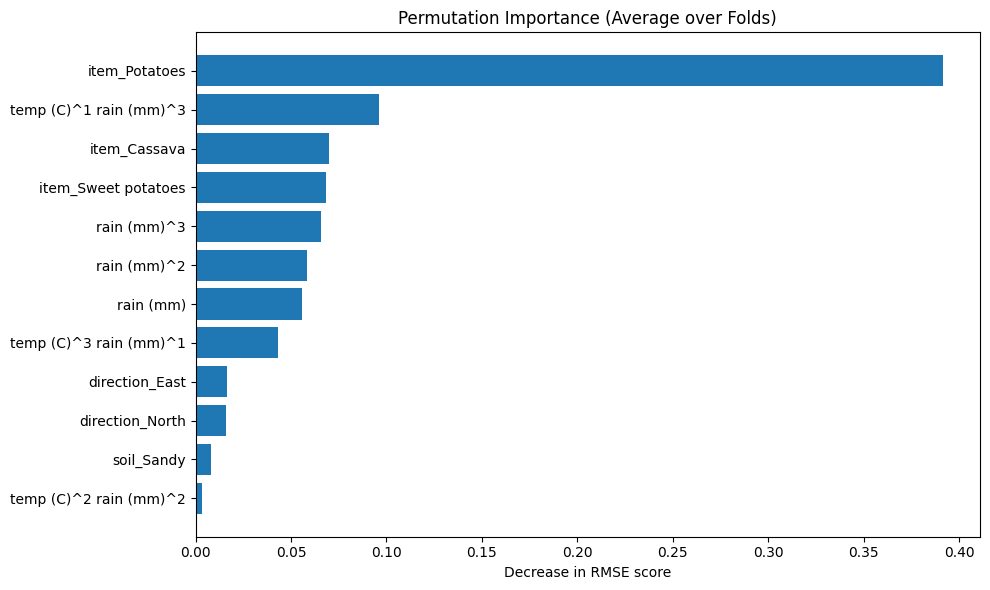

🏃 View run random_forest_permutation at: http://localhost:5000/#/experiments/1/runs/e470f83b24b549829b85b5a8fec5b7c2
🧪 View experiment at: http://localhost:5000/#/experiments/1


(RandomForestRegressor(max_depth=5, n_estimators=10, n_jobs=-1, random_state=42),
 np.float64(1.3516118755647057))

In [27]:
tags = {
    "phase": "baseline",
    "model_family": "random_forest",
    "dataset": "synth+real",
    "columns": "base+polynomial"
}
train_rf_kfold(df_ohe, "yield (t/ha)", n_splits=5, tags=tags)

0it [00:00, ?it/s]2026/03/11 19:56:34 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format."
1it [00:20, 20.14s/it]2026/03/11 19:56:53 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserializati

Final Average RMSE: 1.3639410041241902 | Final Average MAE: 0.9927124688967682
['direction_South' 'direction_West' 'item_Cotton' 'item_Maize'
 'item_Plantains and others' 'item_Rice' 'item_Sorghum' 'item_Soybean'
 'item_Wheat' 'item_Yams' 'soil_Clay' 'soil_Loam' 'soil_Peaty'
 'soil_Sandy' 'soil_Silt' 'synthetic']


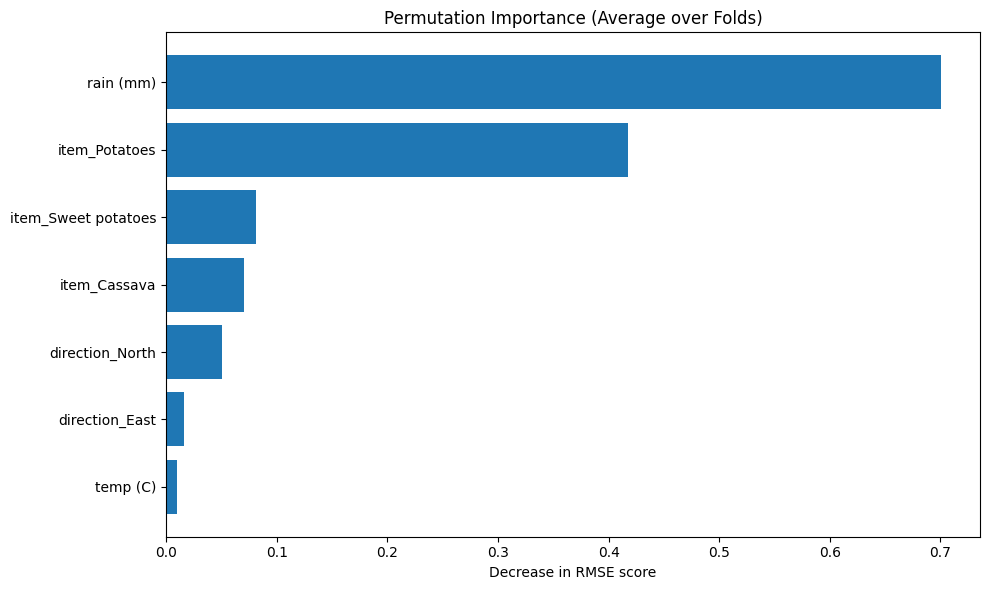

🏃 View run random_forest_permutation at: http://localhost:5000/#/experiments/1/runs/e293b1148a94473498a650070cb42868
🧪 View experiment at: http://localhost:5000/#/experiments/1


(RandomForestRegressor(max_depth=5, n_estimators=10, n_jobs=-1, random_state=42),
 np.float64(1.3639410041241902))

In [28]:
tags = {
    "phase": "baseline",
    "model_family": "random_forest",
    "dataset": "synth+real",
    "columns": "base"
}
train_rf_kfold(df_ohe.drop(polynomial_columns, axis=1), "yield (t/ha)", n_splits=5, tags=tags)

0it [00:00, ?it/s]2026/03/11 19:58:23 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format."
1it [00:28, 28.96s/it]2026/03/11 19:58:53 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserializati

Final Average RMSE: 1.0854604717003018 | Final Average MAE: 0.8863184269138736
['direction_East' 'direction_North' 'direction_South' 'direction_West'
 'item_Cassava' 'item_Cotton' 'item_Maize' 'item_Plantains and others'
 'item_Potatoes' 'item_Rice' 'item_Sorghum' 'item_Soybean'
 'item_Sweet potatoes' 'item_Wheat' 'item_Yams' 'soil_Clay' 'soil_Loam'
 'soil_Peaty' 'soil_Sandy' 'soil_Silt' 'synthetic' 'temp (C)' 'temp (C)^2'
 'temp (C)^3' 'temp (C)^3 rain (mm)^1']


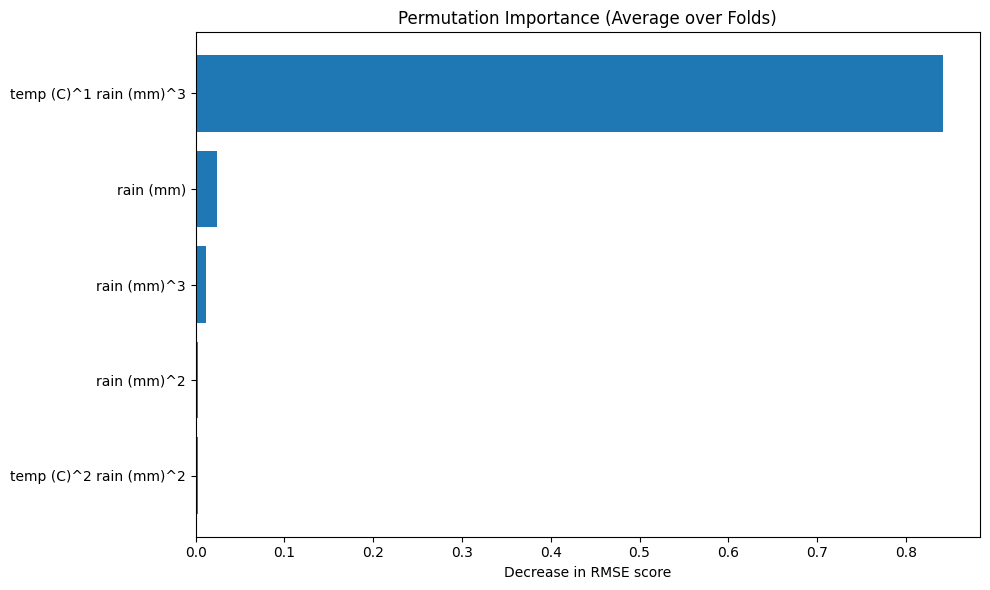

🏃 View run random_forest_permutation at: http://localhost:5000/#/experiments/1/runs/8e4ca1e59b3f47458d791bcc2a403ba5
🧪 View experiment at: http://localhost:5000/#/experiments/1


(RandomForestRegressor(max_depth=5, n_estimators=10, n_jobs=-1, random_state=42),
 np.float64(1.0854604717003018))

In [29]:
tags = {
    "phase": "baseline",
    "model_family": "random_forest",
    "dataset": "real",
    "columns": "base+polynomial"
}
train_rf_kfold(df_ohe[df_ohe["synthetic"] == False], "yield (t/ha)", n_splits=5, tags=tags)

0it [00:00, ?it/s]2026/03/11 20:00:51 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format."
1it [00:18, 18.14s/it]2026/03/11 20:01:09 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserializati

Final Average RMSE: 1.0871882788544158 | Final Average MAE: 0.8877903962025842
['direction_East' 'direction_North' 'direction_South' 'direction_West'
 'item_Cassava' 'item_Cotton' 'item_Maize' 'item_Plantains and others'
 'item_Potatoes' 'item_Rice' 'item_Sorghum' 'item_Soybean'
 'item_Sweet potatoes' 'item_Wheat' 'item_Yams' 'soil_Clay' 'soil_Loam'
 'soil_Peaty' 'soil_Sandy' 'soil_Silt' 'synthetic']


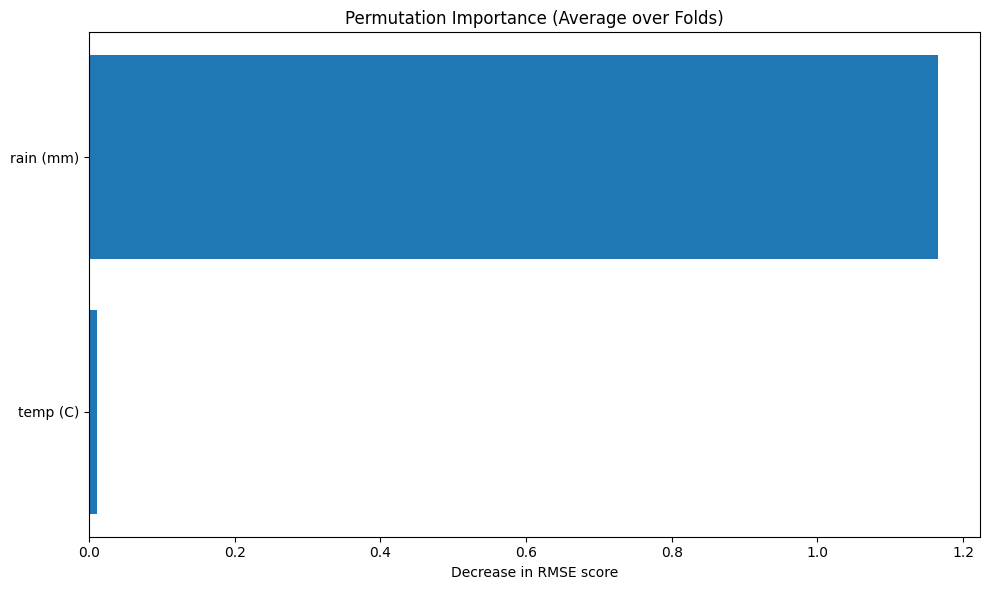

🏃 View run random_forest_permutation at: http://localhost:5000/#/experiments/1/runs/e7291d750c0a46e989d70fae0648d14a
🧪 View experiment at: http://localhost:5000/#/experiments/1


(RandomForestRegressor(max_depth=5, n_estimators=10, n_jobs=-1, random_state=42),
 np.float64(1.0871882788544158))

In [30]:
tags = {
    "phase": "baseline",
    "model_family": "random_forest",
    "dataset": "real",
    "columns": "base"
}
train_rf_kfold(df_ohe.drop(polynomial_columns, axis=1)[df_ohe["synthetic"] == False], "yield (t/ha)", n_splits=5, tags=tags)

# Full Real Dataset

In [31]:
real_df = pd.read_csv("../data/processed/yield_df.csv")
real_df.head()

,Area,Item,temp (C),rain (mm),yield (t/ha),Year,pesticides_tonnes
0,Albania,Maize,16.37,1485.0,3.6613,1990,121.0
1,Albania,Potatoes,16.37,1485.0,6.6667,1990,121.0
2,Albania,"Rice, paddy",16.37,1485.0,2.3333,1990,121.0
3,Albania,Sorghum,16.37,1485.0,1.2500,1990,121.0
4,Albania,Soybeans,16.37,1485.0,0.7000,1990,121.0


In [32]:
cat_columns = ["Item", "Area"]
real_df_ohe = pd.get_dummies(real_df, columns=cat_columns, drop_first=True)
real_df_ohe.head()

,temp (C),rain (mm),yield (t/ha),Year,pesticides_tonnes,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,...,Area_Tajikistan,Area_Thailand,Area_Tunisia,Area_Turkey,Area_Uganda,Area_Ukraine,Area_United Kingdom,Area_Uruguay,Area_Zambia,Area_Zimbabwe
0,16.37,1485.0,3.6613,1990,121.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,16.37,1485.0,6.6667,1990,121.0,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,16.37,1485.0,2.3333,1990,121.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,16.37,1485.0,1.2500,1990,121.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,16.37,1485.0,0.7000,1990,121.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [33]:
real_df_ohe = real_df_ohe.astype("float")

0it [00:00, ?it/s]2026/03/11 20:02:22 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format."
1it [00:08,  8.16s/it]2026/03/11 20:02:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserializati

Final Average RMSE: 5.0831048994916745 | Final Average MAE: 3.147941514912841
['Area_Algeria' 'Area_Angola' 'Area_Argentina' 'Area_Armenia'
 'Area_Austria' 'Area_Azerbaijan' 'Area_Bahamas' 'Area_Bahrain'
 'Area_Bangladesh' 'Area_Belarus' 'Area_Belgium' 'Area_Botswana'
 'Area_Brazil' 'Area_Bulgaria' 'Area_Burkina Faso' 'Area_Burundi'
 'Area_Cameroon' 'Area_Central African Republic' 'Area_Chile'
 'Area_Colombia' 'Area_Croatia' 'Area_Denmark' 'Area_Dominican Republic'
 'Area_Ecuador' 'Area_Egypt' 'Area_El Salvador' 'Area_Eritrea'
 'Area_Estonia' 'Area_Finland' 'Area_France' 'Area_Ghana' 'Area_Greece'
 'Area_Guatemala' 'Area_Guinea' 'Area_Guyana' 'Area_Haiti' 'Area_Honduras'
 'Area_Hungary' 'Area_India' 'Area_Indonesia' 'Area_Iraq' 'Area_Ireland'
 'Area_Italy' 'Area_Jamaica' 'Area_Kazakhstan' 'Area_Kenya' 'Area_Latvia'
 'Area_Lebanon' 'Area_Lesotho' 'Area_Libya' 'Area_Lithuania'
 'Area_Madagascar' 'Area_Malawi' 'Area_Malaysia' 'Area_Mali'
 'Area_Mauritania' 'Area_Mauritius' 'Area_Montenegr

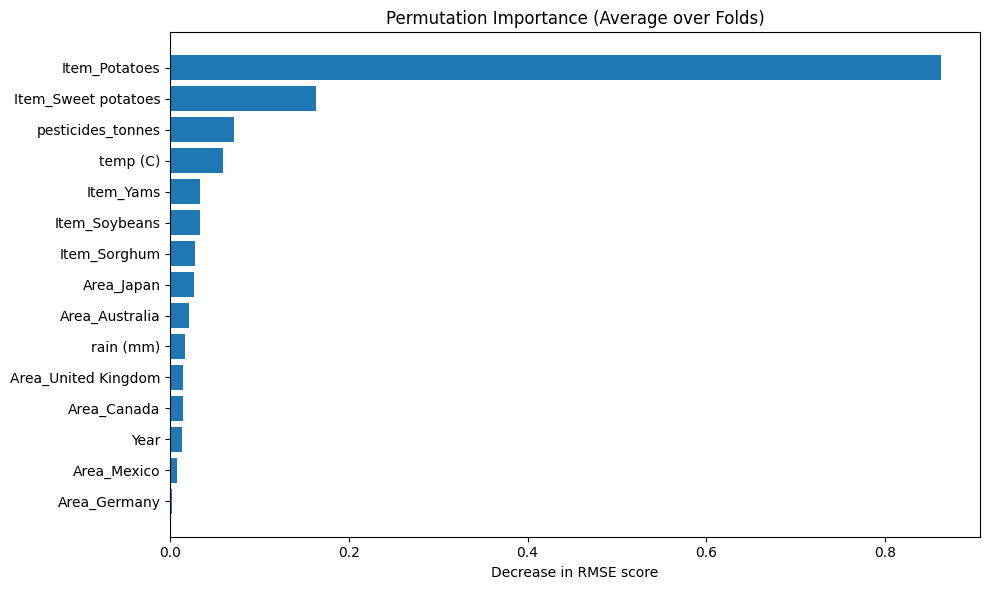

🏃 View run random_forest_permutation at: http://localhost:5000/#/experiments/1/runs/2c8025ee84084df28ce3b3e4ba9f24c0
🧪 View experiment at: http://localhost:5000/#/experiments/1


(RandomForestRegressor(max_depth=5, n_estimators=10, n_jobs=-1, random_state=42),
 np.float64(5.0831048994916745))

In [34]:
params = {
    "n_estimators": 50,
    "max_depth": 10,
    "random_state": 42,
    "n_jobs": -1
}
tags = {
    "phase": "baseline",
    "model_family": "random_forest",
    "dataset": "real+pesticides",
    "columns": "base"
}
train_rf_kfold(real_df_ohe, "yield (t/ha)", n_splits=5, tags=tags)

0it [00:00, ?it/s]2026/03/11 20:03:12 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format."
1it [00:08,  8.25s/it]2026/03/11 20:03:20 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserializati

Final Average RMSE: 5.083237583353013 | Final Average MAE: 3.1479455578884172
['Area_Algeria' 'Area_Angola' 'Area_Argentina' 'Area_Armenia'
 'Area_Austria' 'Area_Azerbaijan' 'Area_Bahamas' 'Area_Bahrain'
 'Area_Bangladesh' 'Area_Belarus' 'Area_Belgium' 'Area_Botswana'
 'Area_Brazil' 'Area_Bulgaria' 'Area_Burkina Faso' 'Area_Burundi'
 'Area_Cameroon' 'Area_Central African Republic' 'Area_Chile'
 'Area_Colombia' 'Area_Croatia' 'Area_Denmark' 'Area_Dominican Republic'
 'Area_Ecuador' 'Area_Egypt' 'Area_El Salvador' 'Area_Eritrea'
 'Area_Estonia' 'Area_Finland' 'Area_France' 'Area_Ghana' 'Area_Greece'
 'Area_Guatemala' 'Area_Guinea' 'Area_Guyana' 'Area_Haiti' 'Area_Honduras'
 'Area_Hungary' 'Area_India' 'Area_Indonesia' 'Area_Iraq' 'Area_Ireland'
 'Area_Italy' 'Area_Jamaica' 'Area_Kazakhstan' 'Area_Kenya' 'Area_Latvia'
 'Area_Lebanon' 'Area_Lesotho' 'Area_Libya' 'Area_Lithuania'
 'Area_Madagascar' 'Area_Malawi' 'Area_Malaysia' 'Area_Mali'
 'Area_Mauritania' 'Area_Mauritius' 'Area_Montenegr

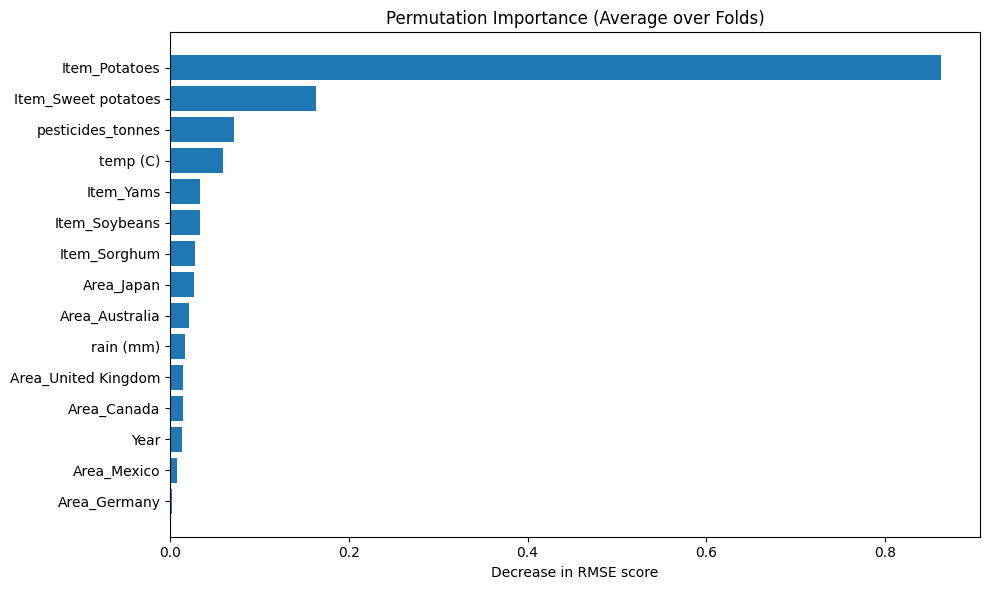

🏃 View run random_forest_permutation at: http://localhost:5000/#/experiments/1/runs/a22bddfacb0249efb69619f915cf06cf
🧪 View experiment at: http://localhost:5000/#/experiments/1


(RandomForestRegressor(max_depth=5, n_estimators=10, n_jobs=-1, random_state=42),
 np.float64(5.083237583353013))

In [35]:
params = {
    "n_estimators": 50,
    "max_depth": 10,
    "random_state": 42,
    "n_jobs": -1
}
tags = {
    "phase": "baseline",
    "model_family": "random_forest",
    "dataset": "real_with_soil_direction",
    "columns": "base"
}
concat = real_df_ohe.copy().reset_index(drop=True)
concat["direction"] = base_df[base_df["synthetic"] == False]["direction"].reset_index(drop=True)
concat["soil"] = base_df[base_df["synthetic"] == False]["soil"].reset_index(drop=True)
concat = pd.get_dummies(concat, columns=["direction", "soil"], drop_first=True)

train_rf_kfold(concat, "yield (t/ha)", n_splits=5, tags=tags)

# XGBoost

In [7]:
def train_xgb_kfold(df, target_col, n_splits=5, tags={}, params={}):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    if not params:
        params = {
            "max_leaves": 10,
            "max_depth": 5,
            "random_state": 42
        }
    
    with mlflow.start_run(run_name="xgboost", tags=tags):
        mlflow.log_params(params)
        
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        final_scores = []
        mae_scores = []
        mape_scores = []
        # Store permutation importance results across folds
        perm_importances = []
        
        for fold, (train_idx, val_idx) in tqdm(enumerate(kf.split(X))):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            model = XGBRegressor(**params)
            model.fit(X_train, y_train)
            
            # 1. Standard Metrics
            fold_preds = model.predict(X_val)
            fold_rmse = root_mean_squared_error(y_val, fold_preds)
            fold_mae = mean_absolute_error(y_val, fold_preds)

            final_scores.append(fold_rmse)
            mae_scores.append(fold_mae) 

            fold_mape = mean_absolute_percentage_error(y_val, fold_preds)
            mape_scores.append(fold_mape)

            # mlflow.log_metric(f"fold_{fold}_rmse", fold_rmse)
            # mlflow.log_metric(f"fold_{fold}_mae", fold_mae)
            
            # 2. Permutation Importance (calculated on validation set)
            # n_repeats=5 is a good balance between speed and statistical significance
            r = permutation_importance(model, X_val, y_val, n_repeats=5, 
                                       random_state=42, n_jobs=-1)
            perm_importances.append(r.importances_mean)
            
        # Calculate Aggregates
        avg_rmse = np.mean(final_scores)
        avg_mae = np.mean(mae_scores)
        avg_mape = np.mean(mape_scores)

        avg_perm_importance = np.mean(perm_importances, axis=0)

        mlflow.log_metric("rmse", avg_rmse)
        mlflow.log_metric("mae", avg_mae)
        mlflow.log_metric("mape", avg_mape)
        
        # Log the final model
        mlflow.sklearn.log_model(model, "xgboost")
        print(f"Final Average RMSE: {avg_rmse} | Final Average MAE: {avg_mae}")

        # 3. Create and Log Importance Plot
        feat_df = pd.DataFrame({
            "feature": X.columns, 
            "permutation_importance": avg_perm_importance
        }).sort_values("permutation_importance", ascending=True)

        zero_importance = feat_df[abs(feat_df["permutation_importance"]) <= 0.001]
        feature_importance = feat_df[abs(feat_df["permutation_importance"]) > 0.001]

        print(zero_importance["feature"].values)
        
        plt.figure(figsize=(10, 10))
        plt.barh(feature_importance["feature"], feature_importance["permutation_importance"])
        plt.xlabel("Decrease in RMSE score")
        plt.title("Permutation Importance (Average over Folds)")
        plt.tight_layout()
        
        # Save and log the plot to MLflow
        fig = plt.gcf()
        mlflow.log_figure(fig, "permutation_importance.png")
        plt.show()

    return model, avg_rmse

0it [00:00, ?it/s]2026/03/11 20:04:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
1it [00:13, 13.96s/it]2026/03/11 20:04:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2it [00:27, 13.92s/it]2026/03/11 20:04:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
3it [00:42, 14.21s/it]2026/03/11 20:04:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
4it [00:57, 14.41s/it]2026/03/11 20:04:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
5it [01:12, 14.42s/it]
2026/03/11 20:05:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution becaus

Final Average RMSE: 1.175503919426016 | Final Average MAE: 0.9114147269915287
['temp (C)^2' 'temp (C)^3' 'item_Cotton' 'soil_Peaty' 'direction_West'
 'item_Wheat' 'item_Rice' 'soil_Loam' 'soil_Clay']


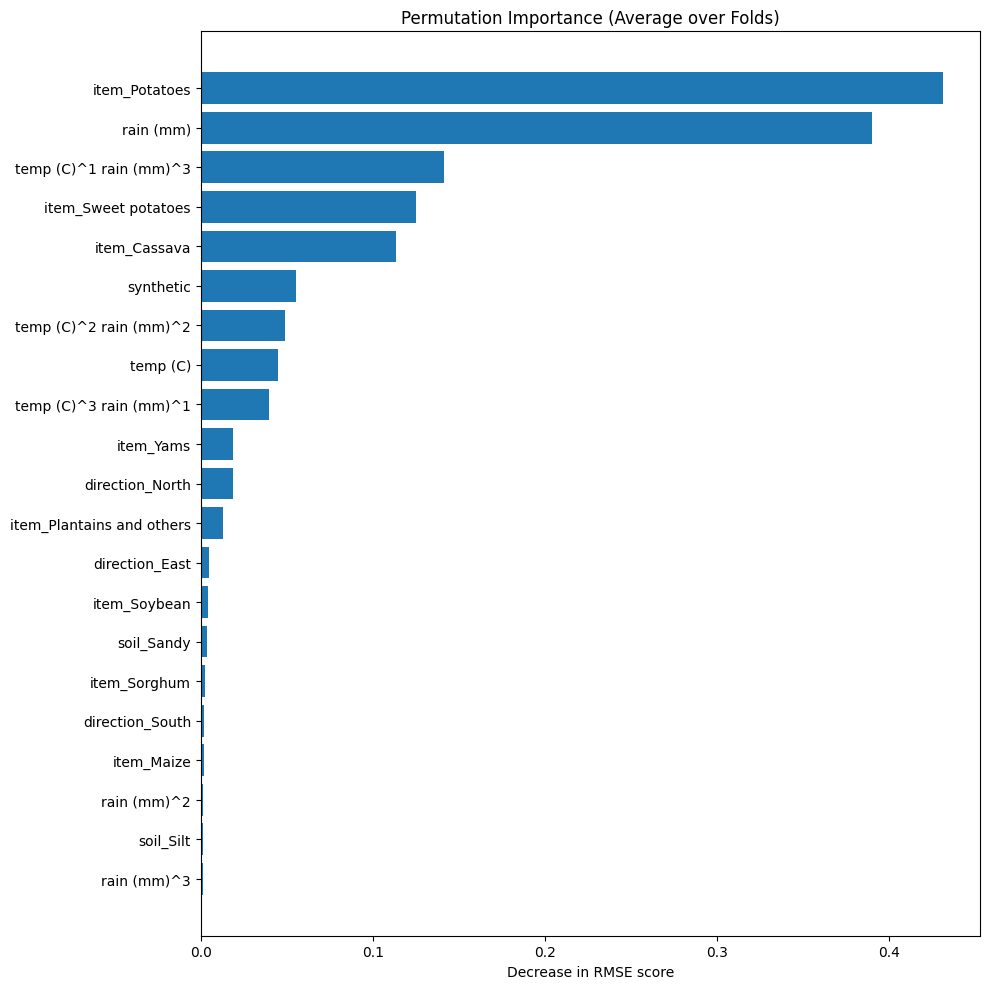

🏃 View run xgboost at: http://localhost:5000/#/experiments/1/runs/76f5ab2bd58a4a74a143b636c0f93ff0
🧪 View experiment at: http://localhost:5000/#/experiments/1


(XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=10, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...),
 np.float64(1.175503919426016))

In [37]:
tags = {
    "phase": "baseline",
    "model_family": "xgboost",
    "dataset": "synth+real",
    "columns": "base+polynomial"
}
train_xgb_kfold(df_ohe, "yield (t/ha)", n_splits=5, tags=tags)

0it [00:00, ?it/s]2026/03/11 20:05:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
1it [00:14, 14.19s/it]2026/03/11 20:05:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2it [00:28, 14.37s/it]2026/03/11 20:05:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
3it [00:43, 14.60s/it]2026/03/11 20:06:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
4it [00:58, 14.69s/it]2026/03/11 20:06:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
5it [01:13, 14.67s/it]
2026/03/11 20:06:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution becaus

Final Average RMSE: 1.0842581337262538 | Final Average MAE: 0.8853529819653335
['soil_Silt' 'direction_East' 'item_Wheat' 'item_Soybean' 'direction_West'
 'soil_Sandy' 'direction_North' 'soil_Peaty' 'item_Cassava'
 'item_Potatoes' 'item_Plantains and others' 'synthetic' 'item_Sorghum'
 'item_Sweet potatoes' 'item_Yams' 'item_Rice' 'soil_Loam' 'item_Maize'
 'direction_South' 'soil_Clay' 'item_Cotton' 'temp (C)^3' 'temp (C)^2']


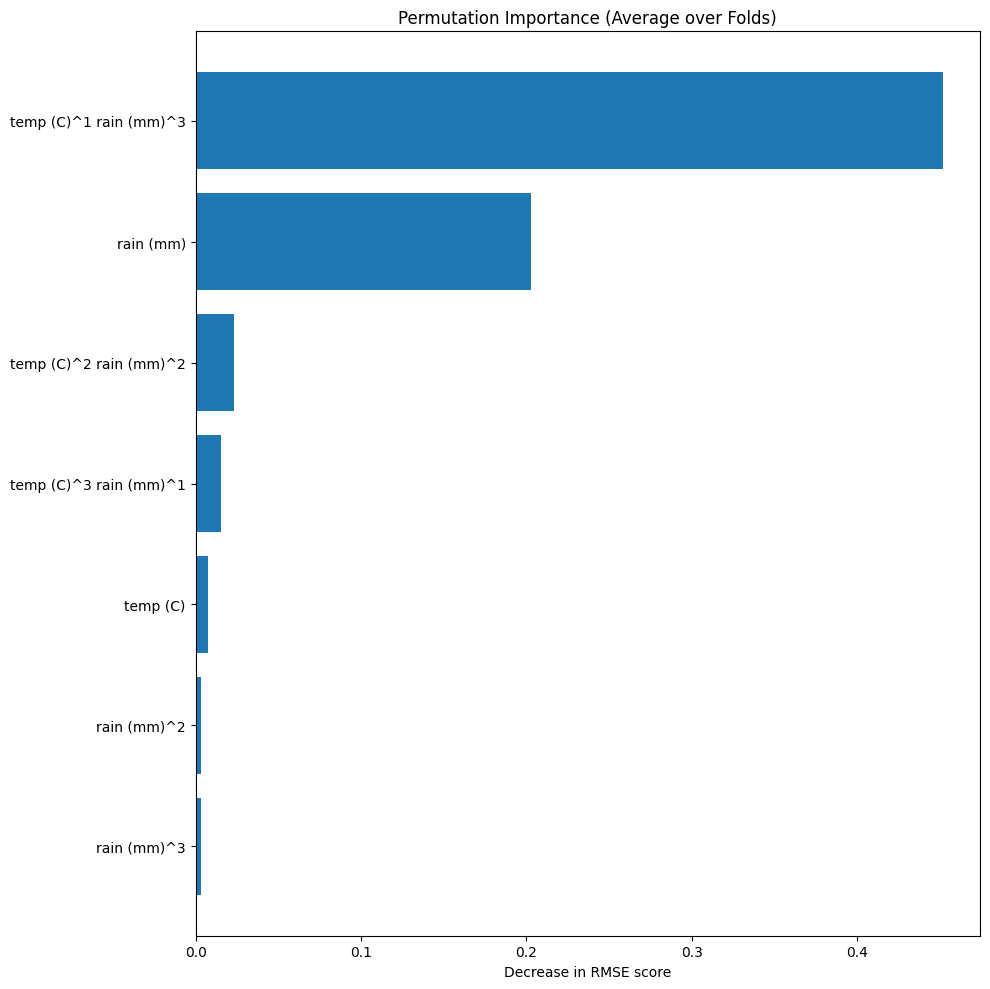

🏃 View run xgboost at: http://localhost:5000/#/experiments/1/runs/93436c54696f4f78aedd4d85e8eefc71
🧪 View experiment at: http://localhost:5000/#/experiments/1


(XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=10, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...),
 np.float64(1.0842581337262538))

In [38]:
tags = {
    "phase": "baseline",
    "model_family": "xgboost",
    "dataset": "real",
    "columns": "base+polynomial"
}
train_xgb_kfold(df_ohe[df_ohe["synthetic"] == False], "yield (t/ha)", n_splits=5, tags=tags)

# Dataset separation based on crop type

In [8]:
knn_df = pd.read_csv("../data/processed/knn_merged.csv")

In [9]:
crop_groups = {crop: knn_df[knn_df['item'] == crop] for crop in knn_df['item'].unique()}
_ = [print(k, len(v)) for k, v in crop_groups.items()]

Wheat 3857
Maize 4121
Rice 3388


In [10]:
from sklearn.dummy import DummyRegressor

for crop, crop_df in crop_groups.items():
    tags = {
        "phase": "baseline",
        "model_family": "dummy_regressor",
        "dataset": crop
    }
    print(crop)
    with mlflow.start_run(experiment_id="1", tags=tags, run_name="linear_regression"):
        lr = DummyRegressor()

        X_train, X_test, y_train, y_test = train_test_split(crop_df.drop("item", axis=1), crop_df["yield (t/ha)"], test_size=0.2, random_state=42)

        lr.fit(X_train, y_train)
        y_pred = lr.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        rmse = root_mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)

        print(f"R2: {r2:.2f}")
        print(f"RMSE: {rmse:.2f}")
        print(f"MAE: {mae:.2f}")
        print(f"MAPE: {mape:.2f}")

        mlflow.log_metric("r2", r2)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("mape", mape)

Wheat


2026/03/21 17:18:18 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/21 17:18:18 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/

R2: -0.00
RMSE: 1.85
MAE: 1.42
MAPE: 0.72
🏃 View run linear_regression at: http://localhost:5000/#/experiments/1/runs/6f0c850dba9d4f3c9955b7f4566d99ce
🧪 View experiment at: http://localhost:5000/#/experiments/1
Maize


2026/03/21 17:18:22 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/21 17:18:22 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/

R2: -0.00
RMSE: 2.71
MAE: 2.16
MAPE: 1.07
🏃 View run linear_regression at: http://localhost:5000/#/experiments/1/runs/eb3549ba8e624c96b9b3d8af79678836
🧪 View experiment at: http://localhost:5000/#/experiments/1
Rice


2026/03/21 17:18:25 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/21 17:18:25 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/

R2: -0.00
RMSE: 1.95
MAE: 1.54
MAPE: 0.49
🏃 View run linear_regression at: http://localhost:5000/#/experiments/1/runs/6a48e44002a34657aeb2d7a7c215be48
🧪 View experiment at: http://localhost:5000/#/experiments/1


Crop: Wheat


0it [00:00, ?it/s]2026/03/11 20:06:35 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/11 20:06:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `nam

Final Average RMSE: 0.3152362638854654 | Final Average MAE: 0.21934402752080245
['Area_Spain' 'Area_Montenegro' 'Area_Bulgaria' 'Area_Finland'
 'Area_Denmark' 'Area_Haiti' 'Area_Lebanon'
 'Area_Central African Republic' 'Area_Egypt' 'Area_Guinea' 'Area_Greece'
 'Area_El Salvador' 'Area_Colombia' 'Area_Dominican Republic'
 'Area_Bahamas' 'Area_Burkina Faso' 'Area_Guyana' 'Area_Jamaica'
 'Area_Senegal' 'Area_Papua New Guinea' 'Area_Mauritius' 'Area_Malaysia'
 'Area_Indonesia' 'Area_Suriname' 'Area_Sri Lanka' 'Area_Nicaragua'
 'Area_Ghana' 'Area_Qatar' 'Area_Azerbaijan' 'Area_Argentina'
 'Area_Belarus' 'Area_Botswana' 'Area_India' 'Area_Croatia' 'Area_Estonia'
 'Area_Tunisia' 'Area_Slovenia' 'Area_Netherlands' 'Area_Romania'
 'Area_Italy' 'Area_Uganda' 'Area_France' 'Area_Norway' 'Area_Belgium'
 'Area_Lithuania' 'Area_Latvia' 'Area_Ukraine' 'Area_Poland' 'Area_Chile'
 'Area_Niger' 'Area_Sweden' 'Area_Mauritania' 'Area_Uruguay'
 'Area_Armenia' 'Area_Saudi Arabia' 'Area_Nepal' 'Area_Brazil'

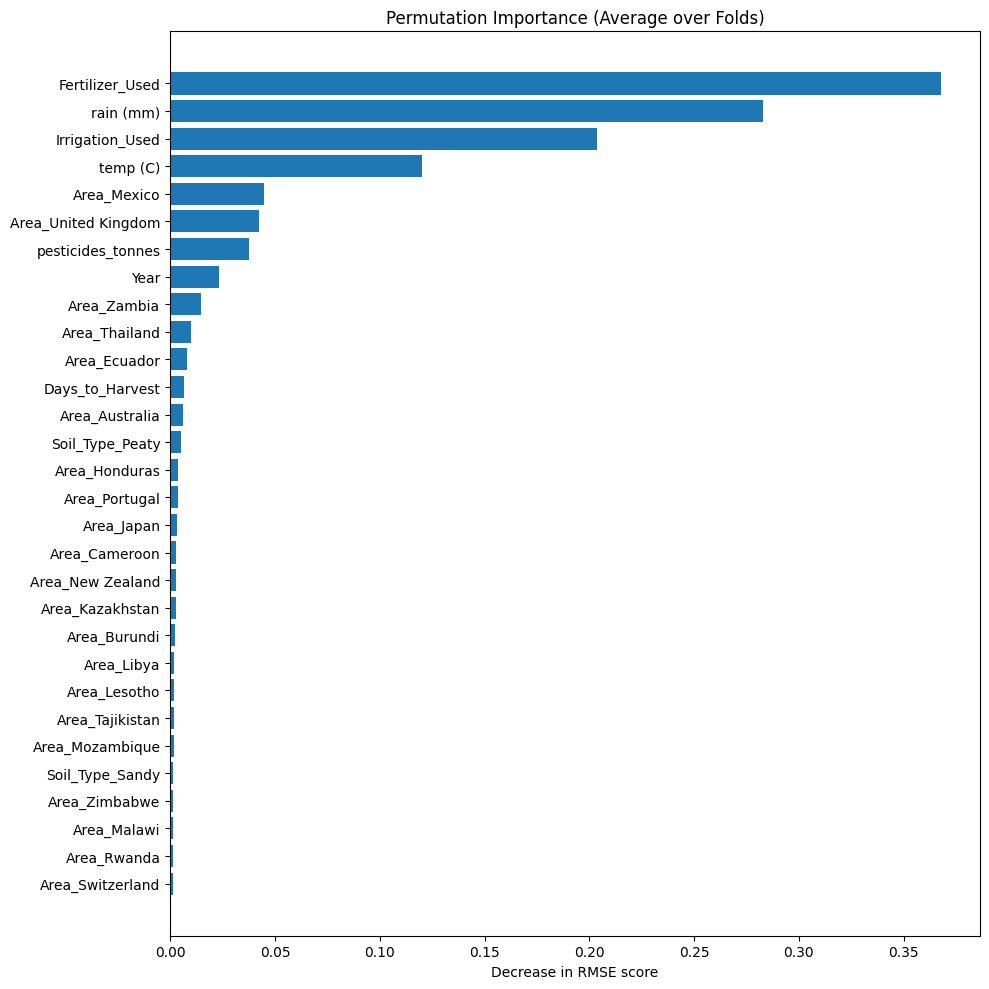

🏃 View run xgboost at: http://localhost:5000/#/experiments/1/runs/27a4e131dbc54519980f0b9f91a0e6e3
🧪 View experiment at: http://localhost:5000/#/experiments/1
--------
Crop: Maize


0it [00:00, ?it/s]2026/03/11 20:07:12 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/11 20:07:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `nam

Final Average RMSE: 0.4709918711457254 | Final Average MAE: 0.3175001180070762
['Area_Algeria' 'Area_Mauritania' 'Area_Ghana' 'Area_Azerbaijan'
 'Area_Estonia' 'Area_Eritrea' 'Area_Egypt' 'Area_Finland' 'Area_Ireland'
 'Area_Latvia' 'Area_Zambia' 'Area_United Kingdom' 'Area_Niger'
 'Area_Norway' 'Area_Peru' 'Area_Colombia' 'Area_Sweden' 'Area_Tunisia'
 'Area_Guatemala' 'Area_Romania' 'Area_Montenegro' 'Area_South Africa'
 'Area_Bulgaria' 'Area_Cameroon' 'Area_Switzerland' 'Area_Malaysia'
 'Area_Iraq' 'Area_Saudi Arabia' 'Area_Central African Republic'
 'Area_Sudan' 'Area_Burkina Faso' 'Area_Armenia' 'Area_Malawi'
 'Area_Belarus' 'Area_Hungary' 'Area_Kazakhstan' 'Area_Namibia'
 'Area_France' 'Area_Nepal' 'Area_Poland' 'Area_Guinea' 'Area_Italy'
 'Area_Haiti' 'Area_Ukraine' 'Area_Guyana' 'Area_Sri Lanka'
 'Area_Botswana' 'Area_El Salvador' 'Area_Argentina' 'Area_Suriname'
 'Area_Germany' 'Area_Jamaica' 'Area_Lebanon' 'Area_Uganda' 'Area_Mali'
 'Area_Madagascar' 'Area_Burundi' 'Area_Hondu

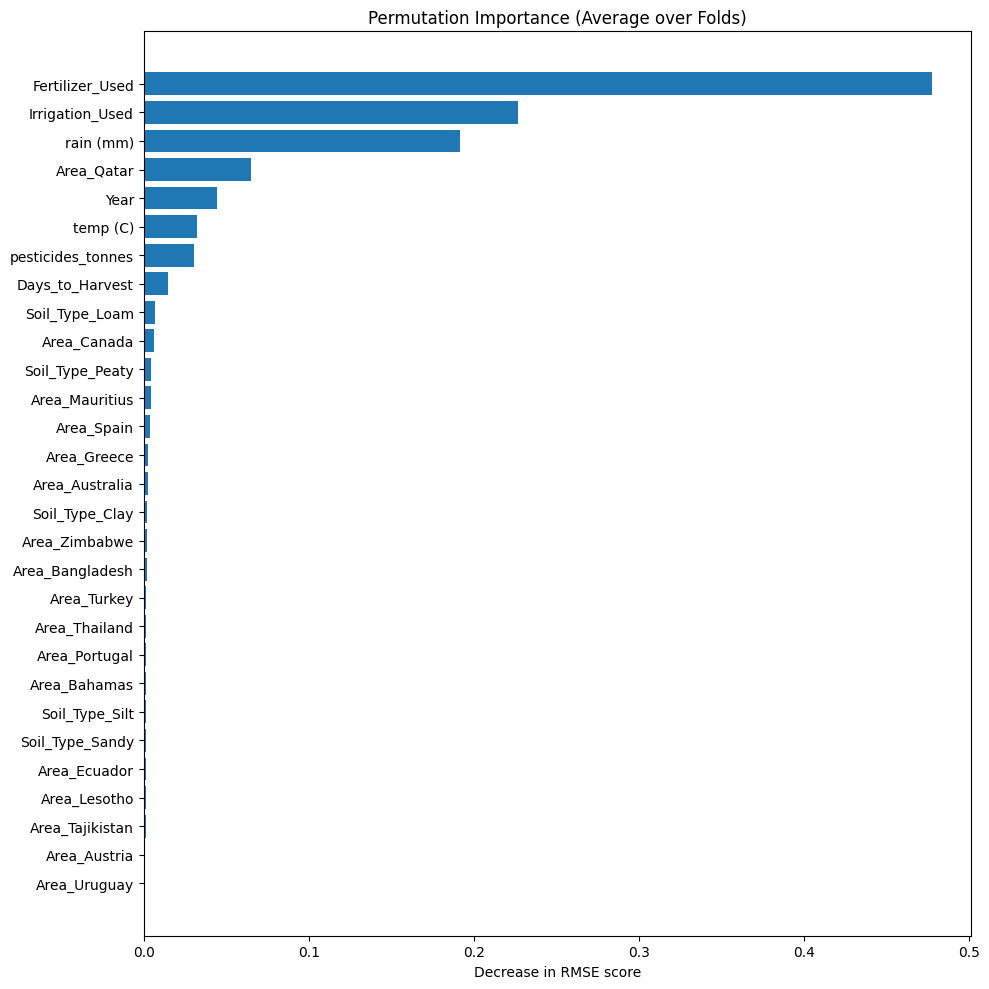

🏃 View run xgboost at: http://localhost:5000/#/experiments/1/runs/92646c4ddd434262a510c92c50b6ed88
🧪 View experiment at: http://localhost:5000/#/experiments/1
--------
Crop: Rice


0it [00:00, ?it/s]2026/03/11 20:07:49 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/11 20:07:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `nam

Final Average RMSE: 0.3647858088264059 | Final Average MAE: 0.2416435033759165
['Area_Mauritius' 'Area_Armenia' 'Area_Canada' 'Area_Belgium'
 'Area_Belarus' 'Area_Austria' 'Area_Bahamas' 'Area_Botswana'
 'Area_Estonia' 'Area_Finland' 'Area_Germany' 'Area_Eritrea' 'Area_Egypt'
 'Area_Denmark' 'Area_Croatia' 'Area_Lebanon' 'Area_Latvia' 'Area_Ireland'
 'Area_Lesotho' 'Area_Haiti' 'Area_Slovenia' 'Area_Poland'
 'Area_Saudi Arabia' 'Area_Qatar' 'Area_Montenegro' 'Area_New Zealand'
 'Area_Netherlands' 'Area_Namibia' 'Area_Lithuania' 'Area_Mauritania'
 'Area_Libya' 'Area_Colombia' 'Area_Sudan' 'Area_Sweden' 'Area_Tunisia'
 'Area_Norway' 'Area_United Kingdom' 'Area_Switzerland' 'Area_Suriname'
 'Area_Ghana' 'Area_Honduras' 'Area_Mali' 'Area_Niger' 'Area_Nicaragua'
 'Area_Bulgaria' 'Area_Uganda' 'Area_Nepal' 'Area_Kenya' 'Area_Guyana'
 'Area_Burkina Faso' 'Area_Ukraine' 'Area_Angola' 'Area_Papua New Guinea'
 'Area_Tajikistan' 'Area_Azerbaijan' 'Area_Madagascar' 'Area_Sri Lanka'
 'Area_Jamaica'

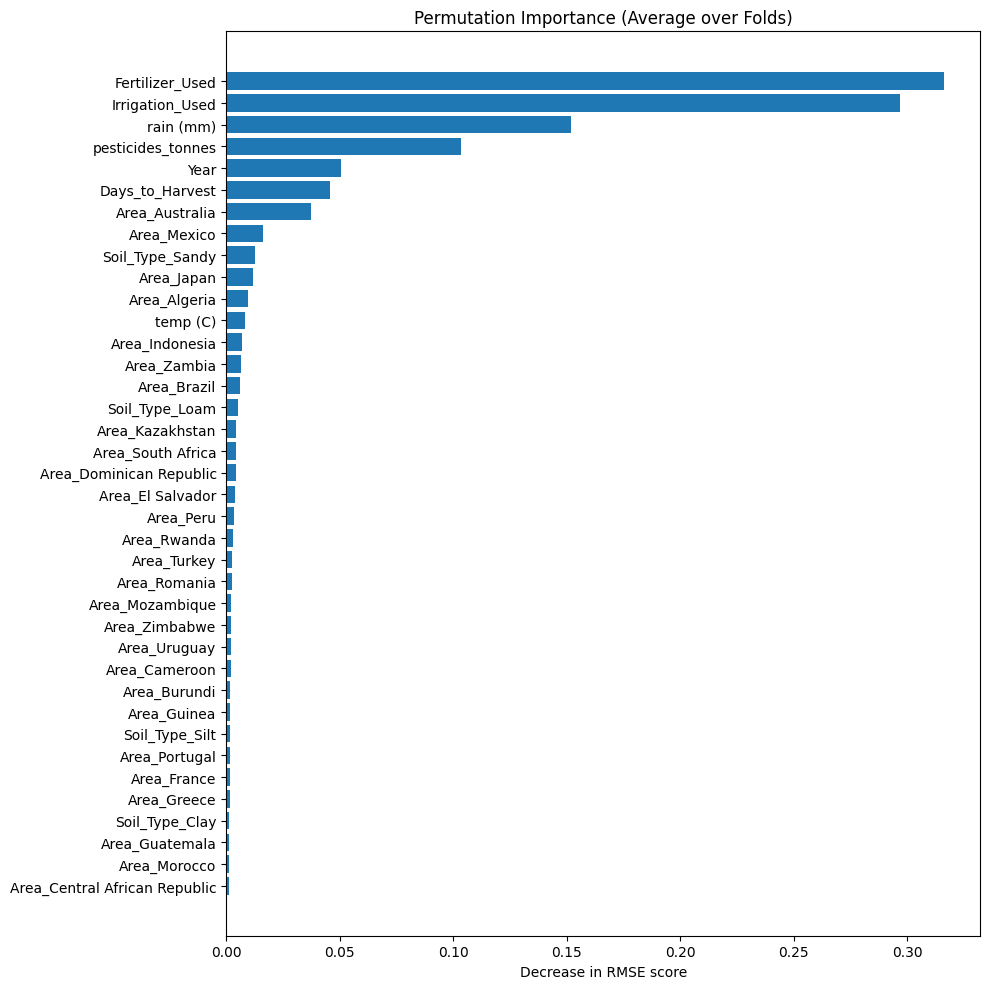

🏃 View run xgboost at: http://localhost:5000/#/experiments/1/runs/efded35da42944378b58e811491d02a6
🧪 View experiment at: http://localhost:5000/#/experiments/1
--------


In [41]:
for crop, crop_df in crop_groups.items():
    print(f"Crop: {crop}")
    
    train_xgb_kfold(crop_df.drop("item", axis=1), "yield (t/ha)", n_splits=5, tags={"phase": "baseline", "model_family": "xgboost", "dataset": crop, "columns": "base"})
    print("--------")

In [12]:
for col in crop_df.columns:
    if col.startswith("Soil_Type"):
        print(col)

Soil_Type_Clay
Soil_Type_Loam
Soil_Type_Peaty
Soil_Type_Sandy
Soil_Type_Silt


In [14]:
col_from_synth = ["Days_to_Harvest", "Irrigation_Used", "Fertilizer_Used", "Soil_Type_Clay", "Soil_Type_Loam", "Soil_Type_Peaty", "Soil_Type_Sandy", "Soil_Type_Silt"]

Crop: Wheat


0it [00:00, ?it/s]

2026/03/21 17:20:40 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/21 17:20:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/0

Final Average RMSE: 0.35619450744138764 | Final Average MAE: 0.24285666350185195
['Area_Estonia' 'Area_Greece' 'Area_Azerbaijan' 'Area_Bahamas'
 'Area_Colombia' 'Area_Dominican Republic' 'Area_El Salvador' 'Area_Egypt'
 'Area_Jamaica' 'Area_Guyana' 'Area_Indonesia' 'Area_Haiti' 'Area_Guinea'
 'Area_Ghana' 'Area_Central African Republic' 'Area_Burkina Faso'
 'Area_Malaysia' 'Area_Mauritius' 'Area_Nicaragua' 'Area_Suriname'
 'Area_Senegal' 'Area_Sri Lanka' 'Area_Papua New Guinea' 'Area_Tunisia'
 'Area_Lebanon' 'Area_Qatar' 'Area_India' 'Area_Uruguay' 'Area_Botswana'
 'Area_Argentina' 'Area_Bulgaria' 'Area_Ukraine' 'Area_Latvia'
 'Area_Uganda' 'Area_Romania' 'Area_Norway' 'Area_Spain' 'Area_Brazil'
 'Area_Niger' 'Area_Armenia' 'Area_Nepal' 'Area_Pakistan'
 'Area_Montenegro' 'Area_Lithuania' 'Area_Belarus' 'Area_Mali'
 'Area_Mauritania' 'Area_Guatemala' 'Area_Bangladesh' 'Area_Sudan'
 'Area_Peru' 'Area_Madagascar' 'Area_Kenya' 'Area_Turkey'
 'Area_Switzerland' 'Area_Angola' 'Area_Rwanda' '

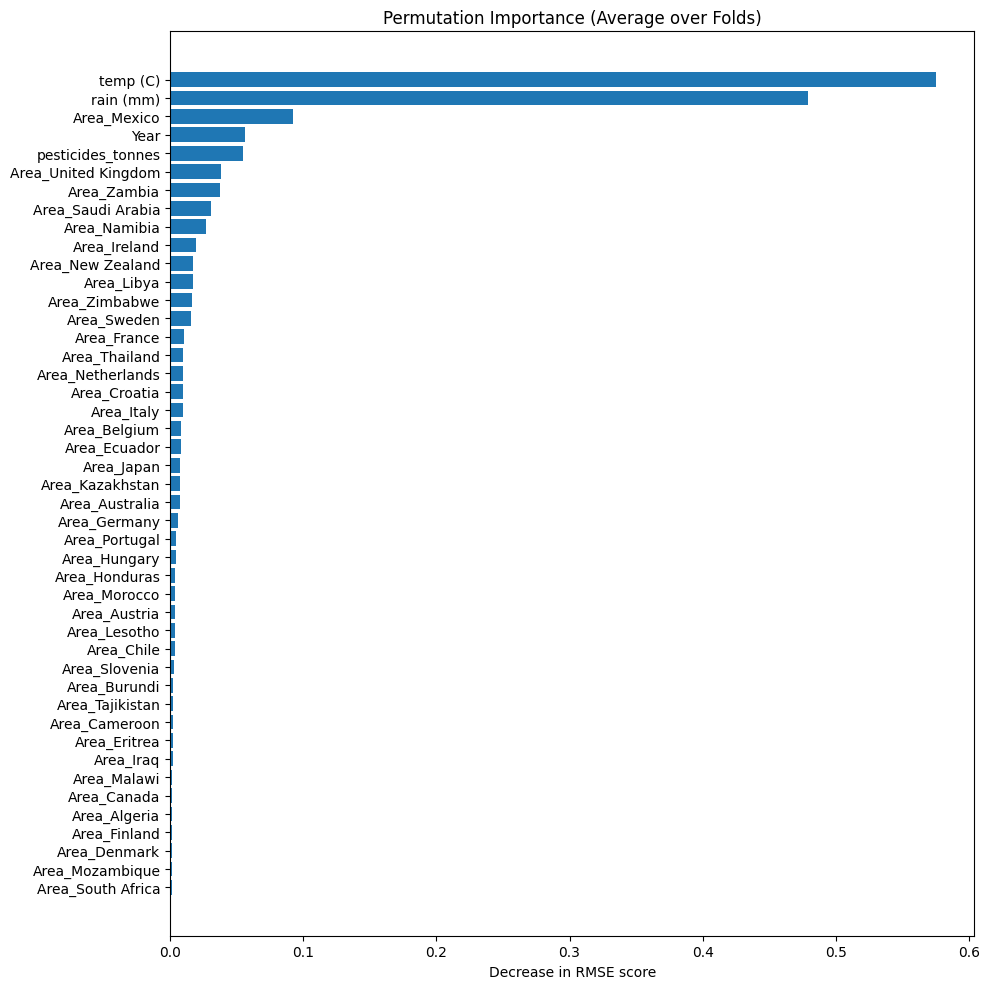

🏃 View run xgboost at: http://localhost:5000/#/experiments/1/runs/26feb28d79584a65ad104fb21c66b985
🧪 View experiment at: http://localhost:5000/#/experiments/1
--------
Crop: Maize


0it [00:00, ?it/s]2026/03/21 17:21:18 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/21 17:21:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `nam

Final Average RMSE: 0.6156233518017644 | Final Average MAE: 0.39557001532545366
['Area_Armenia' 'Area_Bulgaria' 'Area_Algeria' 'Area_Uruguay'
 'Area_Uganda' 'Area_Central African Republic' 'Area_Colombia'
 'Area_Brazil' 'Area_Ghana' 'Area_France' 'Area_Latvia' 'Area_Ireland'
 'Area_Finland' 'Area_Namibia' 'Area_Egypt' 'Area_Estonia' 'Area_Tunisia'
 'Area_Norway' 'Area_United Kingdom' 'Area_Sweden' 'Area_Niger'
 'Area_Cameroon' 'Area_Indonesia' 'Area_Haiti' 'Area_Montenegro'
 'Area_South Africa' 'Area_Burkina Faso' 'Area_Zambia' 'Area_Iraq'
 'Area_Malawi' 'Area_Sudan' 'Area_Mali' 'Area_El Salvador' 'Area_Jamaica'
 'Area_Peru' 'Area_Guyana' 'Area_Guatemala' 'Area_Azerbaijan'
 'Area_Guinea' 'Area_Angola' 'Area_Suriname' 'Area_Sri Lanka' 'Area_Nepal'
 'Area_Slovenia' 'Area_Rwanda' 'Area_Senegal' 'Area_Poland' 'Area_Italy'
 'Area_Eritrea' 'Area_Saudi Arabia' 'Area_Madagascar' 'Area_Kazakhstan'
 'Area_Malaysia' 'Area_Burundi' 'Area_Honduras' 'Area_Germany'
 'Area_Mauritania' 'Area_Nicaragua'

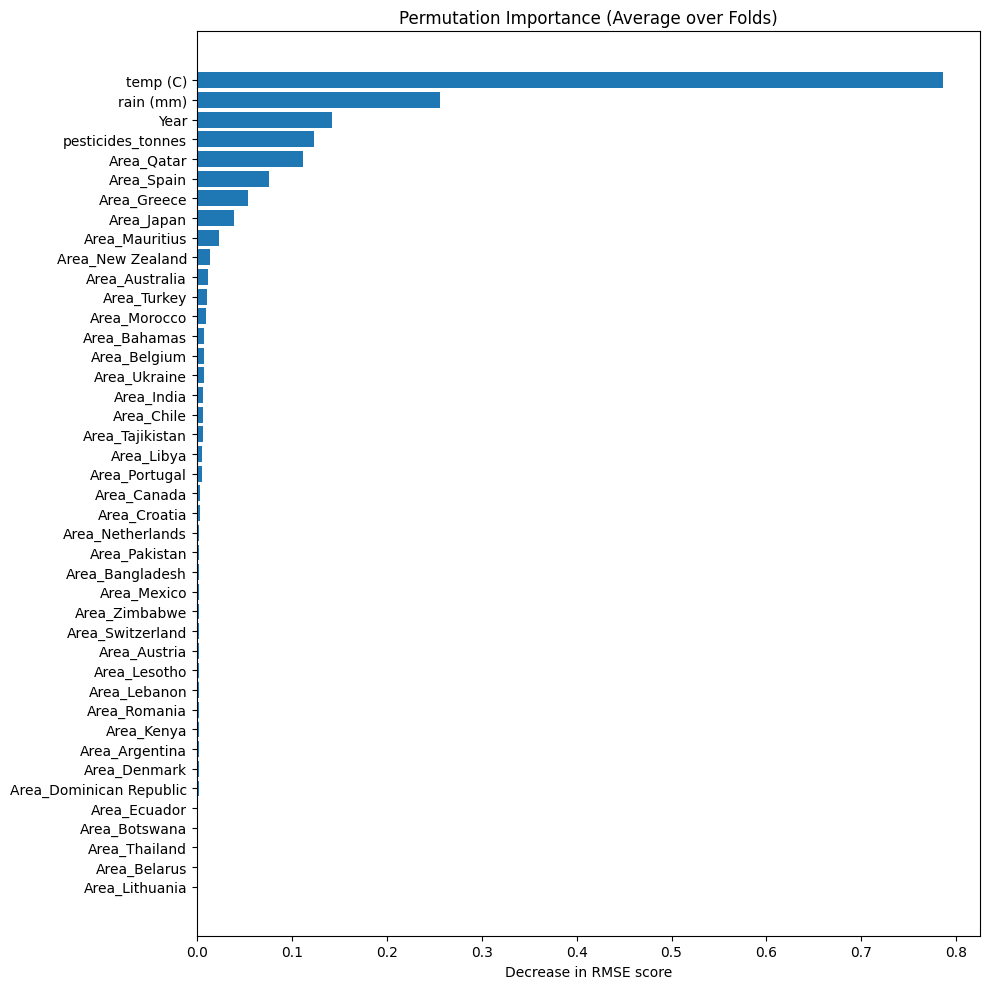

🏃 View run xgboost at: http://localhost:5000/#/experiments/1/runs/ee41d93ed1e748baa3998629bc0b0464
🧪 View experiment at: http://localhost:5000/#/experiments/1
--------
Crop: Rice


0it [00:00, ?it/s]2026/03/21 17:21:53 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/bob/Documents/Dev/openclassrooms/reco-agricole/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/21 17:21:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `nam

Final Average RMSE: 0.42888092888446616 | Final Average MAE: 0.2736945552545015
['Area_Argentina' 'Area_Ghana' 'Area_Bahamas' 'Area_Armenia'
 'Area_Belarus' 'Area_Belgium' 'Area_Austria' 'Area_Botswana'
 'Area_Eritrea' 'Area_Croatia' 'Area_Colombia' 'Area_Egypt' 'Area_Denmark'
 'Area_Germany' 'Area_Estonia' 'Area_Canada' 'Area_Kazakhstan'
 'Area_Lesotho' 'Area_Lebanon' 'Area_Ireland' 'Area_Finland' 'Area_Libya'
 'Area_Lithuania' 'Area_Latvia' 'Area_Qatar' 'Area_Nicaragua'
 'Area_Poland' 'Area_Norway' 'Area_Namibia' 'Area_Netherlands'
 'Area_New Zealand' 'Area_Montenegro' 'Area_Switzerland' 'Area_Tunisia'
 'Area_United Kingdom' 'Area_Saudi Arabia' 'Area_Slovenia' 'Area_Sweden'
 'Area_Chile' 'Area_Haiti' 'Area_Niger' 'Area_Iraq' 'Area_Mali'
 'Area_Burkina Faso' 'Area_Ecuador' 'Area_France' 'Area_Sudan'
 'Area_Hungary' 'Area_Mauritania' 'Area_Uganda' 'Area_Madagascar'
 'Area_Malaysia' 'Area_Sri Lanka' 'Area_Senegal'
 'Area_Central African Republic' 'Area_Bangladesh' 'Area_Honduras'
 'Area

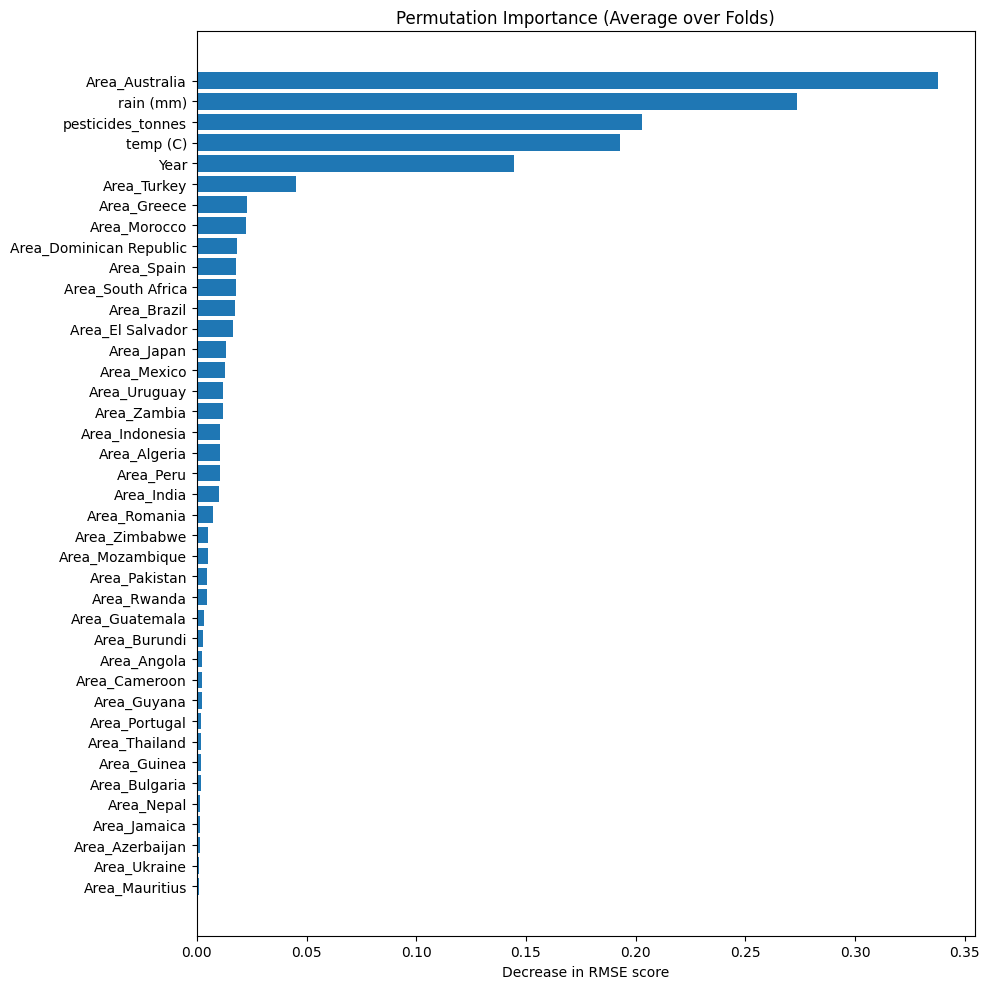

🏃 View run xgboost at: http://localhost:5000/#/experiments/1/runs/7704e765540c49499ac79d367906d760
🧪 View experiment at: http://localhost:5000/#/experiments/1
--------


In [15]:
for crop, crop_df in crop_groups.items():
    print(f"Crop: {crop}")
    
    train_xgb_kfold(crop_df.drop(["item"]+col_from_synth, axis=1), "yield (t/ha)", n_splits=5, tags={"phase": "baseline", "model_family": "xgboost", "dataset": crop, "columns": "only_real"})
    print("--------")